# Python Basics and Data Manipulation

This notebook loads the commodity price CSV, parses and cleans it, filters for selected commodities and the year 2021, computes monthly averages, and visualises the results.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## 1. Load the CSV & Inspection

The raw file has 7 header rows of metadata before the actual data begins. We skip those rows and assign clean column names manually.

The date column uses `DD/MM/YYYY` format, so we pass `dayfirst=True` to `pd.to_datetime`.

In [ ]:
# Skip the 7 metadata rows; row 8 in the file is the first data row
COLUMNS = ["date", "copper", "aluminium", "zinc", "lead", "tin", "crude_oil"]

df = pd.read_csv(
    "../data/MarketData.csv",
    skiprows=7,
    header=None,
    names=COLUMNS,
)

# Parse dates
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Coerce all price columns to numeric
price_cols = ["copper", "aluminium", "zinc", "lead", "tin", "crude_oil"]
df[price_cols] = df[price_cols].apply(pd.to_numeric, errors="coerce")

print(f"Loaded {len(df):,} rows | Date range: {df['date'].min().date()} → {df['date'].max().date()}")
df.head()

Loaded 3,391 rows | Date range: 2010-01-01 → 2022-12-30


,date,copper,aluminium,zinc,lead,tin,crude_oil
0,2010-01-01,7375.0,2230.0,2560.0,2432.0,16950,79.36
1,2010-01-04,7500.0,2267.0,2574.0,2515.0,17450,81.51
2,2010-01-05,7485.0,2302.0,2575.0,2522.5,17375,81.77
3,2010-01-06,7660.0,2377.0,2718.0,2680.0,17825,83.18
4,2010-01-07,7535.0,2310.0,2607.0,2599.0,17475,82.66


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3391 entries, 0 to 3390
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       3391 non-null   datetime64[us]
 1   copper     3391 non-null   float64       
 2   aluminium  3391 non-null   float64       
 3   zinc       3391 non-null   float64       
 4   lead       3391 non-null   float64       
 5   tin        3391 non-null   int64         
 6   crude_oil  3391 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 185.6 KB


The data has no Nan values.

## 2. Filter for Selected Commodities and Year 2021

We assess Copper, Zinc, and Crude Oil.

Since each commodity is its own column (wide format), we:
1. Keep only the relevant columns
2. Filter rows where the year is 2021
3. Melt to long format so each row is one (date, commodity, price) observation as this makes grouping and plotting much cleaner

In [25]:
SELECTED = ["copper", "zinc", "crude_oil"]

# Filter year
df_2021 = df[df["date"].dt.year == 2021][["date"] + SELECTED].copy()

# Melt to long format
df_long = df_2021.melt(id_vars="date", value_vars=SELECTED, var_name="commodity", value_name="price")
df_long.head(10)


,date,commodity,price
0,2021-01-01,copper,7766.0
1,2021-01-04,copper,7860.5
2,2021-01-05,copper,8002.0
3,2021-01-06,copper,8037.5
4,2021-01-07,copper,8179.0
5,2021-01-08,copper,8131.0
6,2021-01-11,copper,7864.0
7,2021-01-12,copper,7975.5
8,2021-01-13,copper,8009.0
9,2021-01-14,copper,8048.5


## 3. Calculate Monthly Average Price

We group by commodity and month, then take the mean settlement price.

`pd.Grouper(key='date', freq='ME')` groups by month-end period cleanly without needing to manually extract year/month.

In [15]:
monthly_avg = (
    df_long
    .groupby(["commodity", pd.Grouper(key="date", freq="ME")])
    ["price"]
    .mean()
    .reset_index()
)

monthly_avg["month"] = monthly_avg["date"].dt.strftime("%b")
monthly_avg["price"] = monthly_avg["price"].round(2)

monthly_avg.head(12)

,commodity,date,price,month
0,copper,2021-01-31,7968.69,Jan
1,copper,2021-02-28,8450.15,Feb
2,copper,2021-03-31,8974.59,Mar
3,copper,2021-04-30,9267.50,Apr
4,copper,2021-05-31,10162.36,May
5,copper,2021-06-30,9656.11,Jun
6,copper,2021-07-31,9480.20,Jul
7,copper,2021-08-31,9382.50,Aug
8,copper,2021-09-30,9327.64,Sep
9,copper,2021-10-31,9647.43,Oct


## 4. Table View

Pivot to wide format for a clean side-by-side comparison.

In [30]:
table = monthly_avg.pivot(index="month", columns="commodity", values="price")

# Reorder months in chronological order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
table = table.reindex(month_order)

table

commodity,copper,crude_oil,zinc
month,,,
Jan,7968.69,51.94,2730.02
Feb,8450.15,59.08,2762.38
Mar,8974.59,62.36,2809.37
Apr,9267.50,61.69,2841.16
May,10162.36,65.21,2982.57
Jun,9656.11,71.35,2967.84
Jul,9480.20,72.55,2962.32
Aug,9382.50,67.71,2996.36
Sep,9327.64,71.44,3048.75


## 5. Chart — Monthly Average Price per Commodity (2021)

Three subplots, one per commodity. Crude Oil uses a separate y-axis scale (USD/barrel) vs the metals (USD/tonne), so separating them avoids a misleading chart.

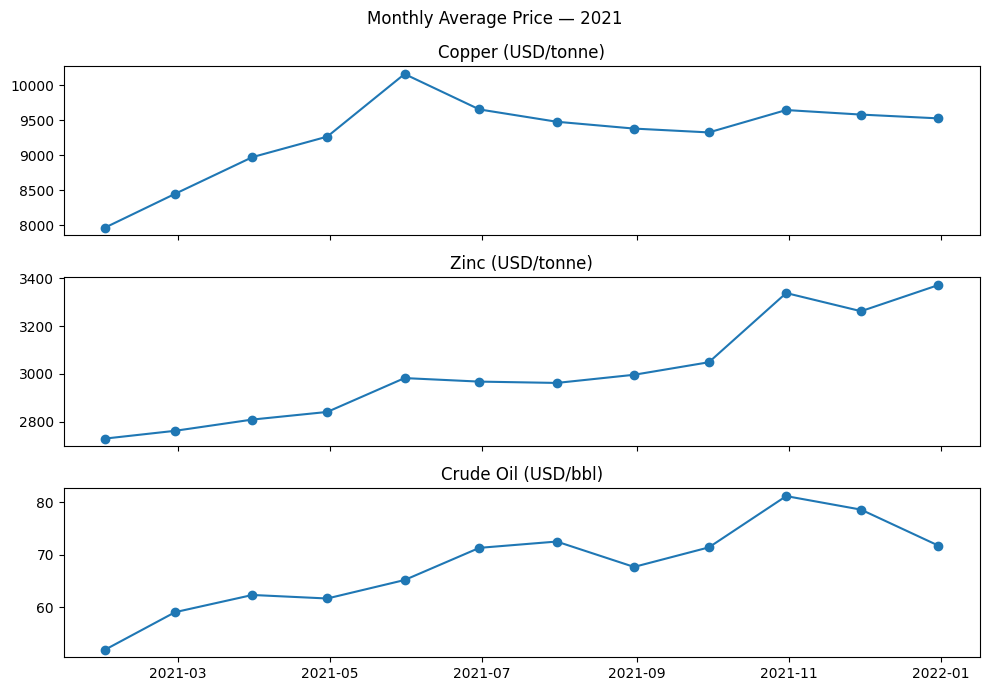

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

LABELS = {
    "copper": "Copper (USD/tonne)",
    "zinc": "Zinc (USD/tonne)",
    "crude_oil": "Crude Oil (USD/bbl)",
}

for ax, commodity in zip(axes, ["copper", "zinc", "crude_oil"]):
    data = monthly_avg[monthly_avg["commodity"] == commodity].sort_values("date")
    ax.plot(data["date"], data["price"],marker='o')
    ax.set_title(LABELS[commodity])

fig.suptitle("Monthly Average Price — 2021")
fig.tight_layout()
plt.show()

## 6. Observations

**Copper** started the year around $8,000/t and hit close to $10,000/t by May, 
then pulled back and stayed roughly flat for the rest of the year.

**Zinc** moved up more gradually, ending the year near $3,371/t in December.

**Crude Oil** trended up all year, going from around $52/bbl in January to 
$81/bbl in October, then dipped slightly toward year-end.

All three moved in the same direction in 2021 which is the post-COVID recovery. They rallied through 2021 as the global economy reopened 
and demand came back faster than supply could respond.